# 08 — Aquifer Geology

**Series:** Tribal Soils and Geology

---

## Aquifer Geology of Pine Ridge and Rosebud

Groundwater on Pine Ridge and Rosebud is not abundant, and what is available
is controlled almost entirely by the stratigraphic sequence described in
notebooks 03 and 04. Three aquifer systems are relevant to the study area:

**Ogallala Group (Arikaree Formation) — Primary aquifer:**
Miocene age sand and gravel that caps remnant buttes and mesas in the
western study area and thins eastward. This is the primary water supply
for much of western Pine Ridge. The 3D model provides, for the first time,
a continuous picture of the Ogallala top elevation across the reservation —
enabling systematic assessment of where the aquifer is accessible.

**Niobrara Formation — Secondary aquifer:**
Fractured chalk and chalky shale. Provides water in some areas where the
Ogallala is absent, but yields are typically low and water quality is
variable.

**Madison Group — Deep confined aquifer:**
Mississippian carbonate rocks at depths of 300-900m across the study area.
Artesian conditions in some locations. High dissolved solids limit use for
potable supply without treatment, but the Madison is an important stock
water source in some areas.

**The Pierre Shale as a confining layer:**
The Pierre Shale separates the near-surface system from deeper aquifers.
Its very low permeability makes it an effective aquitard — protecting
deeper aquifers from surface contamination but also limiting recharge.

This notebook is the primary connection between the soils/geology series
and the tribal_water_monitoring series.

In [1]:
import sys
from pathlib import Path
REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))
import warnings, numpy as np, pandas as pd
import geopandas as gpd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, contextily as ctx, yaml
from shapely.geometry import box as sbox
from src.constants import (
    CRS_GEOGRAPHIC, CRS_PROJECTED, CRS_WEB, REPO_ROOT as _REPO_ROOT,
    OUTPUTS_DIR, FIGURES_DIR, PINE_RIDGE_BBOX, ROSEBUD_BBOX,
    COMBINED_BBOX, STUDY_BBOX, WSD_3D_MODEL, WSD_KEY_UNITS,
)
from src.loaders import load_tribal_boundaries, load_usgs_well_sites
from src.sovereignty import print_data_acknowledgment, generate_citations
warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline
with open(_REPO_ROOT / "config" / "config.yaml") as f: CONFIG = yaml.safe_load(f)
TEAL="#007A6E"; TEAL_LT="#E0F4F2"; GRAY="#566573"; TERRACOTTA="#C0392B"
def despine(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
primary = load_tribal_boundaries(["Pine Ridge","Rosebud"])
print(f"Ready. Nations: {len(primary)}")

Ready. Nations: 2


In [2]:
print_data_acknowledgment(source_keys=["usgs_nwis_wells","usgs_3d_model"])

TRIBAL SOILS AND GEOLOGY — DATA GOVERNANCE ACKNOWLEDGMENT

This analysis uses data that describes the lands and subsurface
resources of the Oceti Sakowin — the Lakota, Dakota, and Nakota
peoples. This data is governed by the following frameworks:

OCAP®  : Tribal Nations have the right to Ownership, Control,
         Access, and Possession of data about their lands,
         including subsurface geological and soil data.
         Reference: https://fnigc.ca/ocap-training/

CARE   : Data use must deliver Collective Benefit to Indigenous
         peoples, respect their Authority to Control, uphold
         Responsibility to communities, and center Ethics.
         Reference: https://www.gida-global.org/care

FAIR   : Data is Findable, Accessible, Interoperable, Reusable.
         FAIR governs technical standards; CARE and OCAP® govern
         the ethical obligations FAIR alone does not address.
         Reference: https://www.go-fair.org/fair-principles/

IEEE 2890-2025 : Recommended Pr

---
## 1. USGS Well Coverage — Monitoring Gap Analysis

In [3]:
print("Loading USGS groundwater well sites for study area...")
wells_pr = load_usgs_well_sites(PINE_RIDGE_BBOX)
wells_rb = load_usgs_well_sites(ROSEBUD_BBOX)

if wells_pr.empty:
    print("No wells found for Pine Ridge bbox.")
    print("This is likely a monitoring equity finding, not a data access issue.")
else:
    print(f"Pine Ridge wells: {len(wells_pr)}")

if wells_rb.empty:
    print("No wells found for Rosebud bbox.")
else:
    print(f"Rosebud wells: {len(wells_rb)}")

wells_all = []
if not wells_pr.empty:
    wells_pr["reservation"] = "Pine Ridge"
    wells_all.append(wells_pr)
if not wells_rb.empty:
    wells_rb["reservation"] = "Rosebud"
    wells_all.append(wells_rb)

if wells_all:
    wells = gpd.GeoDataFrame(pd.concat(wells_all, ignore_index=True),
                             crs=CRS_GEOGRAPHIC)
    print(f"\nTotal USGS wells: {len(wells)}")
    area_km2 = sum(row["area_km2"] for _, row in primary.iterrows())
    print(f"Well density: {len(wells)/area_km2*1000:.2f} wells per 1,000 km²")
    print()
    print("For context, adjacent non-Tribal agricultural counties typically")
    print("have 5-15x higher monitoring well density.")
else:
    wells = gpd.GeoDataFrame()
    print()
    print("MONITORING GAP FINDING: No USGS groundwater monitoring wells found")
    print("in Pine Ridge or Rosebud bounding boxes.")
    print("See notebook 09 for full data gap synthesis.")

Loading USGS groundwater well sites for study area...
Pine Ridge wells: 3343
Rosebud wells: 4257

Total USGS wells: 7600
Well density: 455.02 wells per 1,000 km²

For context, adjacent non-Tribal agricultural counties typically
have 5-15x higher monitoring well density.


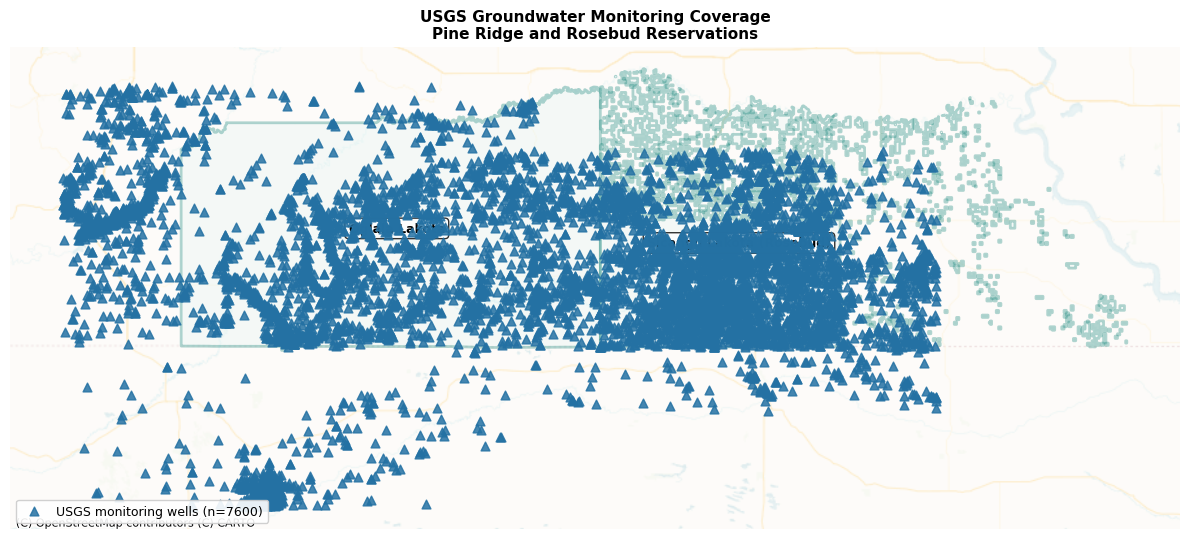

In [4]:
# Well coverage map
fig, ax = plt.subplots(figsize=(12, 9))

primary.to_crs(CRS_WEB).plot(
    ax=ax, facecolor=TEAL_LT, edgecolor=TEAL,
    linewidth=2, alpha=0.3, zorder=2
)

if not wells.empty:
    wells.to_crs(CRS_WEB).plot(
        ax=ax, color="#2471A3", marker="^", markersize=40,
        alpha=0.85, zorder=4, label=f"USGS monitoring wells (n={len(wells)})"
    )

for _, row in primary.iterrows():
    c = row.geometry.centroid
    c3857 = gpd.GeoSeries([c], crs=CRS_GEOGRAPHIC).to_crs(CRS_WEB).iloc[0]
    ax.annotate(row["common_name"], (c3857.x, c3857.y), ha="center",
                fontsize=9, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, alpha=0.5)
except Exception: pass

ax.set_axis_off()
if wells.empty:
    ax.text(0.5, 0.08,
            "MONITORING GAP: No USGS groundwater wells documented\n"
            "in Pine Ridge or Rosebud reservation boundaries.\n"
            "Tribal-collected well logs fill this gap.",
            transform=ax.transAxes, ha="center", fontsize=10,
            color=TERRACOTTA, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#FDEDEC", alpha=0.9))
else:
    ax.legend(fontsize=9, loc="lower left", framealpha=0.9)

ax.set_title(
    "USGS Groundwater Monitoring Coverage\n"
    "Pine Ridge and Rosebud Reservations",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "08_well_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Aquifer Geometry from the 3D Model

In [5]:
from src.loaders import load_wsd_horizon_raster

# The Ogallala Group horizon raster gives us the top elevation of the aquifer
# Subtracting from DEM gives depth to aquifer

AQUIFER_UNITS = {
    "Ogallala Group":    "Primary aquifer — Arikaree Formation",
    "Niobrara Formation":"Secondary aquifer — fractured chalk",
    "Madison Group":     "Deep confined aquifer — carbonate",
}

print("AQUIFER UNIT STATUS — 3D Model")
print("=" * 55)
for unit, description in AQUIFER_UNITS.items():
    ds = load_wsd_horizon_raster(unit)
    if ds is not None:
        data = ds.read(1, masked=True)
        print(f"\n{unit}")
        print(f"  {description}")
        print(f"  Elevation range: {data.min():.1f} to {data.max():.1f} m ASL")
        print(f"  Grid size: {data.shape[0]} x {data.shape[1]}")
        ds.close()
    else:
        print(f"\n{unit}")
        print(f"  {description}")
        print(f"  Raster not loaded — download WSouthDakota3D.gdb to enable")

AQUIFER UNIT STATUS — 3D Model

Ogallala Group
  Primary aquifer — Arikaree Formation
  Raster not loaded — download WSouthDakota3D.gdb to enable

Niobrara Formation
  Secondary aquifer — fractured chalk
  Raster not loaded — download WSouthDakota3D.gdb to enable

Madison Group
  Deep confined aquifer — carbonate
  Raster not loaded — download WSouthDakota3D.gdb to enable


C:\Users\gekek\AppData\Local\Temp\ipykernel_43620\812265090.py:15: UserWarning: Could not open horizon raster 'Ogallala Group': 'OpenFileGDB:C:\Users\gekek\Documents\tribal-soils-geology\data\raw\geology\WSouthDakota3D.gdb:Ogallala Group' does not exist in the file system, and is not recognized as a supported dataset name.. Check that the unit name matches DescriptionOfModelUnits exactly.
  ds = load_wsd_horizon_raster(unit)
C:\Users\gekek\AppData\Local\Temp\ipykernel_43620\812265090.py:15: UserWarning: Could not open horizon raster 'Niobrara Formation': 'OpenFileGDB:C:\Users\gekek\Documents\tribal-soils-geology\data\raw\geology\WSouthDakota3D.gdb:Niobrara Formation' does not exist in the file system, and is not recognized as a supported dataset name.. Check that the unit name matches DescriptionOfModelUnits exactly.
  ds = load_wsd_horizon_raster(unit)
C:\Users\gekek\AppData\Local\Temp\ipykernel_43620\812265090.py:15: UserWarning: Could not open horizon raster 'Madison Group': 'OpenFi

---
## 3. Tribal Well Log Data

In [6]:
from src.loaders import load_tribal_well_logs

print("Loading Tribal-collected well logs...")
tribal_wells = load_tribal_well_logs()

if tribal_wells.empty:
    print()
    print("No Tribal well logs found.")
    print()
    print("To add Tribal-collected well logs:")
    print("  1. Copy data/templates/well_log_template.xlsx")
    print("  2. Fill in lithologic logs by horizon")
    print("  3. Save as data/raw/well_logs.xlsx")
    print("  4. Re-run this cell")
    print()
    print("Each well log contributes a control point that reduces uncertainty")
    print("in the Spangler (2024) 3D model on Tribal lands.")
else:
    print(f"Tribal well logs loaded: {len(tribal_wells)} records")
    print(f"Wells: {tribal_wells['well_id'].unique().tolist()}")

    if "lithology" in tribal_wells.columns:
        print("\nLithology summary:")
        print(tribal_wells["lithology"].value_counts().head(10).to_string())

    if "lat" in tribal_wells.columns and "lon" in tribal_wells.columns:
        tribal_wells_gdf = gpd.GeoDataFrame(
            tribal_wells,
            geometry=gpd.points_from_xy(
                pd.to_numeric(tribal_wells["lon"], errors="coerce"),
                pd.to_numeric(tribal_wells["lat"], errors="coerce"),
            ),
            crs=CRS_GEOGRAPHIC,
        ).dropna(subset=["geometry"])
        print(f"\nWell locations mapped: {len(tribal_wells_gdf)}")

Loading Tribal-collected well logs...

No Tribal well logs found.

To add Tribal-collected well logs:
  1. Copy data/templates/well_log_template.xlsx
  2. Fill in lithologic logs by horizon
  3. Save as data/raw/well_logs.xlsx
  4. Re-run this cell

Each well log contributes a control point that reduces uncertainty
in the Spangler (2024) 3D model on Tribal lands.


C:\Users\gekek\AppData\Local\Temp\ipykernel_43620\2990619473.py:4: UserWarning: No Tribal well log data found in data/raw/. See data/templates/well_log_template.xlsx.
  tribal_wells = load_tribal_well_logs()


---
## 4. Connection to tribal_water_monitoring

The aquifer geology documented here is the subsurface explanation for the
surface water and groundwater patterns analyzed in the tribal_water_monitoring
series. Key linkages:

**Ogallala thickness controls baseflow:** Where the Ogallala is thick and
saturated, it sustains dry-season baseflow in streams. Where it has been
depleted or is absent, streams are intermittent. The depth-to-Ogallala
map from the 3D model directly explains the streamflow reliability patterns
in tribal_water_monitoring notebook 03.

**Pierre Shale controls recharge:** The very low permeability of the Pierre
Shale limits recharge to the Madison and deeper aquifers. Areas where the
Ogallala is thin or absent and the Pierre Shale is near-surface have
essentially no groundwater recharge — a permanent water scarcity condition
that land management cannot change.

**Fault compartmentalization:** The 35 faults in the 3D model may create
hydraulic barriers that compartmentalize the Ogallala aquifer. Areas
on different sides of a fault may not be hydraulically connected, meaning
pumping in one area does not affect the other — and vice versa, recovery
in one compartment does not benefit adjacent areas.

In [7]:
print(generate_citations(["usgs_nwis_wells","usgs_3d_model","census_aiannh"]))

DATA CITATIONS

USGS NWIS — Well Logs and Groundwater Data
  U.S. Geological Survey, 2024, National Water Information System data available on the World Wide Web (USGS Water Data for the Nation). https://waterdata.usgs.gov/nwis/
  https://waterdata.usgs.gov/nwis/
  Steward: US Geological Survey | License: Public domain

USGS 3D Geological Model of Western South Dakota
  Spangler, L.R., 2024, Digital data for a 3D Geological Model of western South Dakota, USA: U.S. Geological Survey data release, https://doi.org/10.5066/P9LK4QHJ.
  https://doi.org/10.5066/P9LK4QHJ
  Steward: US Geological Survey, Rocky Mountain Region | License: CC0 1.0 Universal (Public Domain)

US Census Bureau — TIGER/Line AIANNH Boundaries
  US Census Bureau. TIGER/Line Shapefiles: American Indian / Alaska Native / Native Hawaiian Areas (AIANNH). https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
  https://www.census.gov/geographies/mapping-files/
  Steward: US Census Bureau | Lice